# Cyber MCQ Evaluation Results Visualization

This notebook visualizes the performance of different models on cybersecurity MCQ benchmarks.

Models:
- **Vanilla**: Base Gemma-2-9b-it model
- **Scoped**: Model with SAE scoping applied
- **SFT**: Supervised fine-tuned model
- **Scoped Recovered**: Scoped model with recovery training

Datasets:
- SecQA v1 and v2
- WMDP Cyber
- CyberMetric

In [14]:
import json
from pathlib import Path
import pandas as pd
import re

In [15]:
# Configuration
EXPERIMENTS_DIR = Path(".")  # Assuming notebook is in experiments/
OUTPUT_PATTERN = "outputs_eval_gemma9b*_cyber_size112_max_tokens1024"

# If True, prefer *_rechecked.json files over *.json when both exist
PREFER_RECHECKED = True

# Model name detection based on folder name patterns
# Order matters: more specific patterns first
MODEL_PATTERNS = [
    ("scoped_recovered_no_sae", "Scoped Recovered (no SAE)"),
    ("scoped_recovered", "Scoped Recovered (Yes SAE)"),  # Must check before "scoped"
    ("_sft_", "SFT"),
    ("_scoped_", "Scoped"),
    # Vanilla is the default - folder has "cyber" but none of the above patterns
]

# Dataset display name mapping
DATASET_SHORT_NAMES = {
    "zefang-liu/secqa (secqa_v1, test)": "SecQA v1",
    "zefang-liu/secqa (secqa_v2, test)": "SecQA v2",
    "cais/wmdp (wmdp-cyber, test)": "WMDP Cyber",
    "khangmacon/cybermetric-10000": "CyberMetric",
}

In [16]:
def detect_model_type(folder_name: str) -> str:
    """Detect model type from folder name."""
    folder_lower = folder_name.lower()
    for pattern, model_name in MODEL_PATTERNS:
        if pattern in folder_lower:
            return model_name
    # Default to Vanilla if no other pattern matches
    return "Vanilla"


def get_json_files_with_rechecked_priority(folder: Path, prefer_rechecked: bool) -> list[Path]:
    """Get JSON files, prioritizing rechecked versions if flag is set.

    If prefer_rechecked is True:
    - For each base file (e.g., foo.json), check if foo_rechecked.json exists
    - If rechecked exists, use it instead of the base file
    - Rechecked files are identified by the _rechecked suffix before .json

    Returns list of JSON files to load.
    """
    all_json_files = list(folder.glob("*.json"))

    # Separate rechecked files from base files
    rechecked_files = {}  # stem without _rechecked -> rechecked file path
    base_files = {}  # stem -> base file path

    for json_file in all_json_files:
        stem = json_file.stem
        if stem.endswith("_rechecked_semantic"): # XXX broke on purpose lol to get the other judge
            base_stem = stem[: -len("_rechecked_semantic")] # XXX broke on purpose lol to get the other judge
            rechecked_files[base_stem] = json_file
        else:
            base_files[stem] = json_file

    # Determine which files to use
    files_to_load = []
    used_rechecked = []
    used_base = []

    for stem, base_file in base_files.items():
        if prefer_rechecked and stem in rechecked_files:
            files_to_load.append(rechecked_files[stem])
            used_rechecked.append(stem)
        else:
            files_to_load.append(base_file)
            if stem in rechecked_files:
                used_base.append(stem)  # Had rechecked but didn't use it

    # Also include any rechecked files that don't have a base file
    for stem, rechecked_file in rechecked_files.items():
        if stem not in base_files:
            files_to_load.append(rechecked_file)

    # Report what was loaded
    if used_rechecked:
        print(f"    Using rechecked: {used_rechecked}")
    if used_base and prefer_rechecked:
        print(f"    Using base (no rechecked available): {used_base}")

    return files_to_load


def load_statistics_from_folder(folder: Path, prefer_rechecked: bool = PREFER_RECHECKED) -> dict:
    """Load all statistics from JSON files in a folder.

    If prefer_rechecked is True, prioritize *_rechecked.json files over *.json.
    """
    stats = {}
    json_files = get_json_files_with_rechecked_priority(folder, prefer_rechecked)

    for json_file in json_files:
        try:
            with open(json_file) as f:
                data = json.load(f)
            if "statistics" in data:
                stats.update(data["statistics"])
        except Exception as e:
            print(f"Error loading {json_file}: {e}")
    return stats

In [17]:
# Find all output folders
output_folders = sorted(EXPERIMENTS_DIR.glob(OUTPUT_PATTERN))
print(f"Found {len(output_folders)} output folders:")
for folder in output_folders:
    model_type = detect_model_type(folder.name)
    print(f"  {folder.name} -> {model_type}")

Found 5 output folders:
  outputs_eval_gemma9b_cyber_size112_max_tokens1024 -> Vanilla
  outputs_eval_gemma9b_scoped_cyber_size112_max_tokens1024 -> Scoped
  outputs_eval_gemma9b_scoped_recovered_cyber_size112_max_tokens1024 -> Scoped Recovered (Yes SAE)
  outputs_eval_gemma9b_scoped_recovered_no_sae_cyber_size112_max_tokens1024 -> Scoped Recovered (no SAE)
  outputs_eval_gemma9b_sft_cyber_size112_max_tokens1024 -> SFT


In [18]:
# Load all statistics
all_stats = {}
for folder in output_folders:
    model_type = detect_model_type(folder.name)
    stats = load_statistics_from_folder(folder)
    if stats:
        all_stats[model_type] = stats
        print(f"Loaded {len(stats)} datasets for {model_type}")

print(f"\nTotal models loaded: {len(all_stats)}")
print(f"Models: {list(all_stats.keys())}")

Loaded 4 datasets for Vanilla
    Using rechecked: ['secqa', 'wmdp_cybermetric']
Loaded 4 datasets for Scoped
    Using rechecked: ['wmdp_cybermetric', 'secqa']
Loaded 4 datasets for Scoped Recovered (Yes SAE)
Loaded 4 datasets for Scoped Recovered (no SAE)
    Using rechecked: ['secqa', 'wmdp_cybermetric']
Loaded 4 datasets for SFT

Total models loaded: 5
Models: ['Vanilla', 'Scoped', 'Scoped Recovered (Yes SAE)', 'Scoped Recovered (no SAE)', 'SFT']


In [19]:
# Build accuracy table (n_models x n_datasets)
def build_accuracy_table(all_stats: dict, metric: str = "accuracy") -> pd.DataFrame:
    """Build a table of model x dataset with specified metric."""
    rows = []
    for model_name, stats in all_stats.items():
        row = {"Model": model_name}
        for dataset_full, dataset_short in DATASET_SHORT_NAMES.items():
            if dataset_full in stats and stats[dataset_full].get("evaluated"):
                value = stats[dataset_full].get(metric)
                row[dataset_short] = value
            else:
                row[dataset_short] = None
        rows.append(row)

    df = pd.DataFrame(rows)
    # Set model order
    model_order = ["Vanilla", "Scoped", "SFT", "Scoped Recovered (no SAE)", "Scoped Recovered (Yes SAE)"]
    df["Model"] = pd.Categorical(df["Model"], categories=model_order, ordered=True)
    df = df.sort_values("Model").reset_index(drop=True)
    df = df.set_index("Model")
    return df

## Accuracy Table

Main results: accuracy across models and datasets.

In [20]:
accuracy_df = build_accuracy_table(all_stats, "accuracy")

# Format as percentages
accuracy_pct = accuracy_df.map(lambda x: f"{x:.1%}" if pd.notna(x) else "N/A")
print("Accuracy (percentage):")
display(accuracy_pct)

Accuracy (percentage):


,SecQA v1,SecQA v2,WMDP Cyber,CyberMetric
Model,,,,
Vanilla,100.0%,98.0%,50.9%,29.5%
Scoped,56.4%,57.0%,31.2%,12.5%
SFT,98.2%,96.0%,42.9%,45.5%
Scoped Recovered (no SAE),100.0%,97.0%,49.1%,29.5%
Scoped Recovered (Yes SAE),91.8%,90.0%,44.6%,31.2%


In [21]:
# Styled table with color gradient
def style_accuracy_table(df: pd.DataFrame):  # -> pd.io.formats.style.Styler:
    """Apply color gradient styling to accuracy table."""
    # Note: axis=None can fail with NaN values, so we use default (column-wise)
    return df.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1).format("{:.1%}", na_rep="N/A")


style_accuracy_table(accuracy_df)

,SecQA v1,SecQA v2,WMDP Cyber,CyberMetric
Model,,,,
Vanilla,100.0%,98.0%,50.9%,29.5%
Scoped,56.4%,57.0%,31.2%,12.5%
SFT,98.2%,96.0%,42.9%,45.5%
Scoped Recovered (no SAE),100.0%,97.0%,49.1%,29.5%
Scoped Recovered (Yes SAE),91.8%,90.0%,44.6%,31.2%


## Conditional Accuracy Table

Accuracy computed only on valid (non-invalid, non-failed) responses.

In [22]:
cond_accuracy_df = build_accuracy_table(all_stats, "conditional_accuracy")
style_accuracy_table(cond_accuracy_df)

,SecQA v1,SecQA v2,WMDP Cyber,CyberMetric
Model,,,,
Vanilla,100.0%,98.0%,52.8%,35.1%
Scoped,71.3%,67.1%,43.2%,21.2%
SFT,100.0%,100.0%,45.3%,45.5%
Scoped Recovered (no SAE),100.0%,97.0%,50.5%,37.1%
Scoped Recovered (Yes SAE),94.4%,91.8%,52.6%,34.0%


## Invalid Response Rate

Percentage of responses that couldn't be parsed.

In [23]:
def build_invalid_rate_table(all_stats: dict) -> pd.DataFrame:
    """Build a table of invalid response rates."""
    rows = []
    for model_name, stats in all_stats.items():
        row = {"Model": model_name}
        for dataset_full, dataset_short in DATASET_SHORT_NAMES.items():
            if dataset_full in stats and stats[dataset_full].get("evaluated"):
                invalid = stats[dataset_full].get("invalid", 0)
                total = stats[dataset_full].get("total", 1)
                row[dataset_short] = invalid / total if total > 0 else 0
            else:
                row[dataset_short] = None
        rows.append(row)

    df = pd.DataFrame(rows)
    model_order = ["Vanilla", "Scoped", "SFT", "Scoped Recovered"]
    df["Model"] = pd.Categorical(df["Model"], categories=model_order, ordered=True)
    df = df.sort_values("Model").reset_index(drop=True)
    df = df.set_index("Model")
    return df


invalid_rate_df = build_invalid_rate_table(all_stats)

# Style with reversed color (lower is better)
invalid_rate_df.style.background_gradient(cmap="RdYlGn_r", vmin=0, vmax=1, axis=None).format("{:.1%}", na_rep="N/A")  # Reversed: red=high, green=low

KeyError: '`Styler.apply` and `.map` are not compatible with non-unique index or columns.'

## Detailed Statistics Table

In [24]:
def build_detailed_stats_table(all_stats: dict) -> pd.DataFrame:
    """Build a detailed table with all statistics."""
    rows = []
    for model_name, stats in all_stats.items():
        for dataset_full, dataset_stats in stats.items():
            if not dataset_stats.get("evaluated"):
                continue
            dataset_short = DATASET_SHORT_NAMES.get(dataset_full, dataset_full)
            rows.append(
                {
                    "Model": model_name,
                    "Dataset": dataset_short,
                    "Accuracy": dataset_stats.get("accuracy"),
                    "Cond. Accuracy": dataset_stats.get("conditional_accuracy"),
                    "Correct": dataset_stats.get("correct"),
                    "Invalid": dataset_stats.get("invalid"),
                    "Total": dataset_stats.get("total"),
                }
            )

    df = pd.DataFrame(rows)
    model_order = ["Vanilla", "Scoped", "SFT", "Scoped Recovered"]
    df["Model"] = pd.Categorical(df["Model"], categories=model_order, ordered=True)
    df = df.sort_values(["Model", "Dataset"]).reset_index(drop=True)
    return df


detailed_df = build_detailed_stats_table(all_stats)

# Format percentages
detailed_styled = detailed_df.style.format(
    {
        "Accuracy": "{:.1%}",
        "Cond. Accuracy": "{:.1%}",
    },
    na_rep="N/A",
)
detailed_styled

,Model,Dataset,Accuracy,Cond. Accuracy,Correct,Invalid,Total
0,Vanilla,CyberMetric,29.5%,35.1%,33,18,112
1,Vanilla,SecQA v1,100.0%,100.0%,110,0,110
2,Vanilla,SecQA v2,98.0%,98.0%,98,0,100
3,Vanilla,WMDP Cyber,50.9%,52.8%,57,4,112
4,Scoped,CyberMetric,12.5%,21.2%,14,46,112
5,Scoped,SecQA v1,56.4%,71.3%,62,23,110
6,Scoped,SecQA v2,57.0%,67.1%,57,15,100
7,Scoped,WMDP Cyber,31.2%,43.2%,35,31,112
8,SFT,CyberMetric,45.5%,45.5%,51,0,112
9,SFT,SecQA v1,98.2%,100.0%,108,2,110


## Bar Chart Visualization

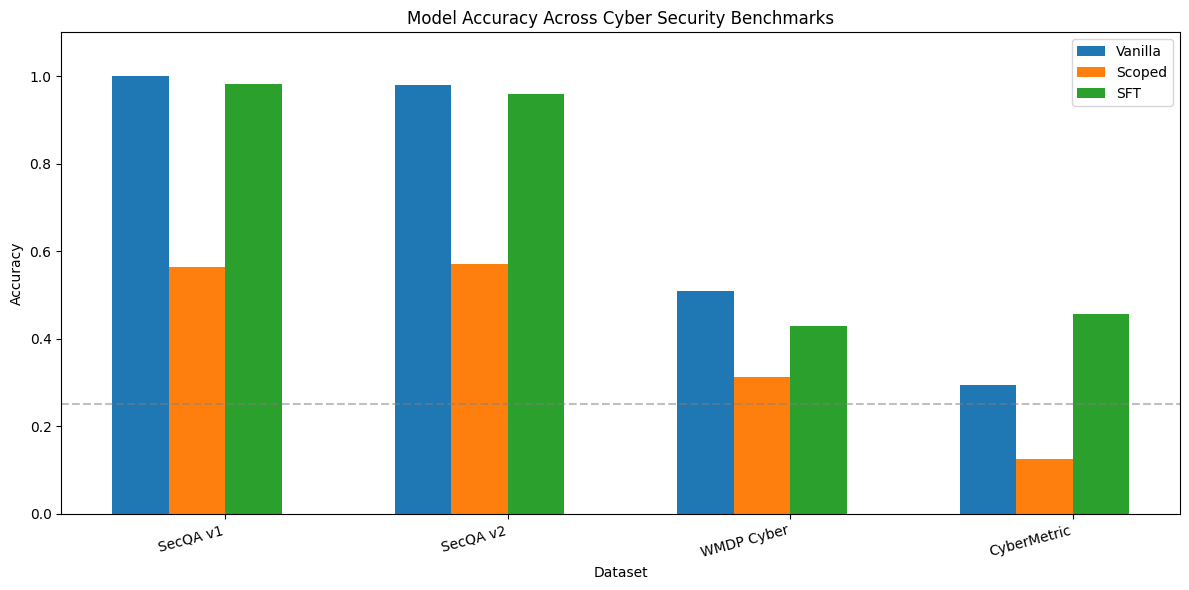

In [25]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

datasets = list(DATASET_SHORT_NAMES.values())
models = ["Vanilla", "Scoped", "SFT", "Scoped Recovered"]
x = np.arange(len(datasets))
width = 0.2

for i, model in enumerate(models):
    if model in accuracy_df.index:
        values = [accuracy_df.loc[model, ds] if pd.notna(accuracy_df.loc[model, ds]) else 0 for ds in datasets]
        ax.bar(x + i * width, values, width, label=model)

ax.set_xlabel("Dataset")
ax.set_ylabel("Accuracy")
ax.set_title("Model Accuracy Across Cyber Security Benchmarks")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(datasets, rotation=15, ha="right")
ax.legend()
ax.set_ylim(0, 1.1)
ax.axhline(y=0.25, color="gray", linestyle="--", alpha=0.5, label="Random baseline (25%)")

plt.tight_layout()
plt.show()

## Summary Statistics

In [26]:
# Average accuracy per model across datasets
print("Average Accuracy per Model:")
avg_accuracy = accuracy_df.mean(axis=1)
for model, acc in avg_accuracy.items():
    print(f"  {model}: {acc:.1%}")

print("\nAverage Accuracy per Dataset:")
avg_by_dataset = accuracy_df.mean(axis=0)
for ds, acc in avg_by_dataset.items():
    print(f"  {ds}: {acc:.1%}")

Average Accuracy per Model:
  Vanilla: 69.6%
  Scoped: 39.3%
  SFT: 70.6%
  Scoped Recovered (no SAE): 68.9%
  Scoped Recovered (Yes SAE): 64.4%

Average Accuracy per Dataset:
  SecQA v1: 89.3%
  SecQA v2: 87.6%
  WMDP Cyber: 43.8%
  CyberMetric: 29.6%
